# AGC ttbar — coffea-casa

Same workflow, same analysis code - the facility changes to `CoffeaCasaFactory`, which connects to coffea-casa's pre-configured Dask cluster (`tls://localhost:8786`) and ships the analysis code and required packages to the workers. Run this notebook **inside a coffea-casa JupyterLab session**.

> Coffea-casa note: if you install custom packages on workers, use a **fixed** number of workers (min == max). With adaptive scaling, a freshly added worker lacks the packages and can stall the run.

This notebook also demonstrates **chunk-level fault tolerance**: `with_failure=True` corrupts one file URL on purpose.

In [1]:
import sys

from coffea_workflow import Step, Workflow, Fileset, Analysis, Plotting, RunConfig, ExecutorConfig, run
from coffea_workflow import facilities
from ttbar_analysis import get_fileset, run_analysis, plotting_1

In [2]:
step_fileset = Step(
    name="Fileset_ttbar",
    step_type=Fileset,
    builder=get_fileset,
    builder_params={"with_failure": True,
                    "n_files_max_per_sample": 2},  # -1 for the full AGC
    output="fileset_dict",
)
step_analysis = Step(
    name="Analysis_ttbar",
    step_type=Analysis,
    builder=run_analysis,
    builder_params={"use_inference": False},       # ML inference needs xgboost + models/
    input="fileset_dict",
    output="analysis_payload",
)
step_plotting = Step(
    name="Plot_ttbar",
    step_type=Plotting,
    builder=plotting_1,
    input="analysis_payload",
)

workflow = Workflow()
workflow.add(step_fileset)
workflow.add(step_analysis, depends_on=[step_fileset])
workflow.add(step_plotting, depends_on=[step_analysis])

Step(name='Plot_ttbar', step_type=<class 'coffea_workflow.artifacts.Plotting'>, builder=<function plotting_1 at 0x7f7dee2022a0>, builder_params=None, facility=None, executor_config=None, input='analysis_payload', output=None)

## Facility

The factory does the boilerplate: Dask `Client` construction, package installation on workers (`worker_packages`), and uploading the analysis module and `utils/` (`worker_files`). It is closed automatically at the end of `run()`.

In [3]:
facility = facilities.CoffeaCasaFactory(
    worker_packages=("coffea>=2026.7.0", ),
    worker_files=("ttbar_analysis.py", "utils", "corrections.json"),
)

## Run(demo-size)

The run is kept small with the workflow's own knobs, no code changes: `datasets` restricts to the corrupted dataset plus the two smallest ones (≈4.4M events instead of 19.5M), and `percentage=50` makes **single-file chunks** — 6 in total. 

Workflow DAG:
  [0] Fileset_ttbar -> Fileset builder=<function get_fileset at 0x7f7def5eb2e0>
  [1] Analysis_ttbar -> Analysis builder=<function run_analysis at 0x7f7deebf1bc0>
  [2] Plot_ttbar -> Plotting builder=<function plotting_1 at 0x7f7dee2022a0>
Edges:
  Fileset_ttbar -> Analysis_ttbar
  Analysis_ttbar -> Plot_ttbar

Run config:
  Strategy:  by_dataset
  Executor:  DaskExecutor  workers=None
  Facility:  CoffeaCasaFactory

Executing step 'Fileset_ttbar' of type 'Fileset' with the user code <function get_fileset at 0x7f7def5eb2e0> and user parameters {'with_failure': True, 'n_files_max_per_sample': 2}
processes in fileset: ['ttbar__nominal', 'ttbar__scaledown', 'ttbar__scaleup', 'ttbar__ME_var', 'ttbar__PS_var', 'single_top_s_chan__nominal', 'single_top_t_chan__nominal', 'single_top_tW__nominal', 'wjets__nominal']

example of information in fileset:
['root://eeeeexrootd-local.unl.edu:1094//store/user/AGC/nanoAOD/ST_s-channel_4f_InclusiveDecays_13TeV-amcatnlo-pythia8/cmsopendata2

Output()

Output()

Output()


execution took 62.07 seconds
Successfully processed!
------------------------------------
Processing fileset_chunk_1.json


...

Output()

Output()


execution took 26.23 seconds
Successfully processed!
------------------------------------
Processing fileset_chunk_5.json


Output()


execution took 7.50 seconds
Successfully processed!
  -> materialized at .cache_coffea_casa_failure/Analysis/b1656d720bf690b9ac0818fef577ff7aa40a0e025b26a6b15ba93332e155ee4e

Executing step 'Plot_ttbar' of type 'Plotting' with the user code <function plotting_1 at 0x7f7dee2022a0> and user parameters None
dict_keys(['builder', 'n_chunks_total', 'n_chunks_ok', 'failures', 'processor_result'])
  -> materialized at .cache_coffea_casa_failure/Plotting/b3f8bda676c6b0a5b7638c95d070cdd346bbef4973b2ceccba0ae127aaac4dd8


=== Run Summary ===
  ✓  Fileset_ttbar                  Fileset
  !  Analysis_ttbar                 Analysis             5/6 chunks OK
       FAILED fileset_chunk_3.json: Err(OSError('[demo] unreachable replica: root://eeeeexrootd-local.unl.edu:1094//store/user/AGC/nanoAOD/ST_s-channel_4f_InclusiveDecays_13TeV-amcatnlo-pythia8/cmsopendata2015_single_top_s_chan_19394_PU25nsData2015v1_76X_mcRun2_asymptotic_v12-v1_00000_0000.root'))
  ✓  Plot_ttbar                     Plotting



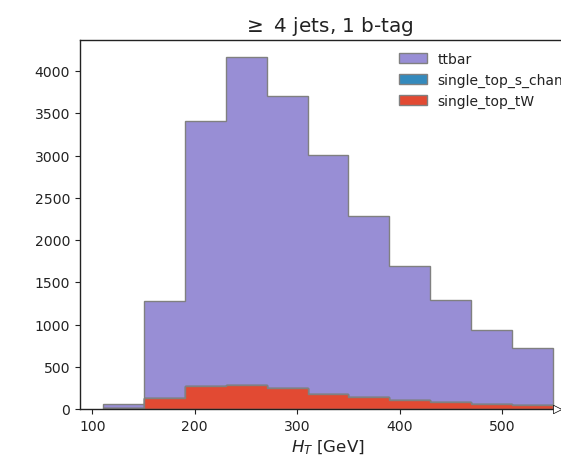

In [4]:
config = RunConfig(
    strategy="by_dataset",
    percentage=50,                             # 1-file chunks: failure isolated to one file
    datasets=["ttbar__nominal",                # the dataset with the broken URL
              "single_top_s_chan__nominal",    # two smallest datasets
              "single_top_tW__nominal"],
    cache_dir=".cache_coffea_casa_failure",
    facility=facility,
    executor_config=ExecutorConfig(executor_type="DaskExecutor"),
)

result = run(workflow, config)